# TAREA 03 Manuel Ytuza Cusirramos

1. Simular lanzamiento de una moneda con random (50 lanzamientos) y plotear resultados.





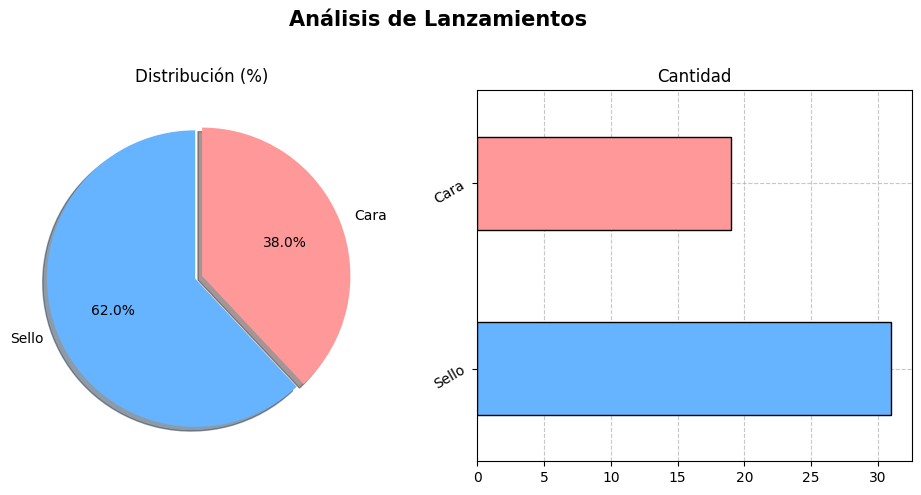

In [11]:
import random
import pandas as pd
import matplotlib.pyplot as plt

# 50 lanzamientos random
lanzamientos = random.choices(
    ["Cara", "Sello"],
    k =50
    )

# crear DataFrame
df = pd.DataFrame({"Resultado": lanzamientos})

# define indice de 1 al 50
df.index = range(1, 51)

# organiza grafico 1 fila y dos columnas
fig, axs = plt.subplots(1,2, figsize=(10,5))

#definir titulo y posicion
fig.suptitle("Análisis de Lanzamientos", fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])

# crear grafico de barras directamente y determinar posicion
conteo_pie = df["Resultado"].value_counts(normalize= True).plot(
    kind="pie",                 # tipo de gráfico: torta
    autopct="%1.1f%%",          # mostrar porcentaje con 1 decimal
    startangle=90,              # rotación inicial
    colors=["#66b3ff", "#ff9999"],  # colores personalizados
    explode=(0.05, 0),          # separar ligeramente la primera categoría
    shadow=True,                # sombra para efecto visual
    ax=axs[0],                  # posición : primer gráfico
    title="Distribución (%)"    # titulo del gráfico
    )

# crear grafico de Torta directamente y determinar posicion
conteo_bar = df["Resultado"].value_counts( ).plot(
    kind="barh",                 # tipo de gráfico: barras horizontales
    color=["#66b3ff", "#ff9999"],  # colores
    edgecolor="black",          # bordes negros para definir mejor las barras
    ax=axs[1],                  # posición : segundo gráfico
    title="Cantidad"            # titulo del gráfico

)

axs[1].tick_params(axis='y', rotation=30)  # etiquetas 30 grados
axs[0].set_ylabel("") #quita texto del eje y
axs[1].set_ylabel("") #quita texto del eje y
axs[1].set_xlabel("") #quita texto del eje x
axs[1].grid(axis="y", linestyle="--", alpha=0.7) #linea horizontales
axs[1].grid(axis="x", linestyle="--", alpha=0.7) #lineas verticales
axs[1].set_axisbelow(True) #grillas atras del texto

plt.show()

 2. Simular lanzamiento con moneda con truco, cara sale el 70% de veces (50 lanzamientos) y plotear resultados.

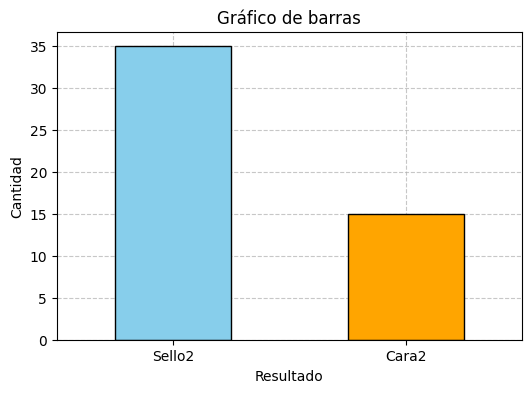

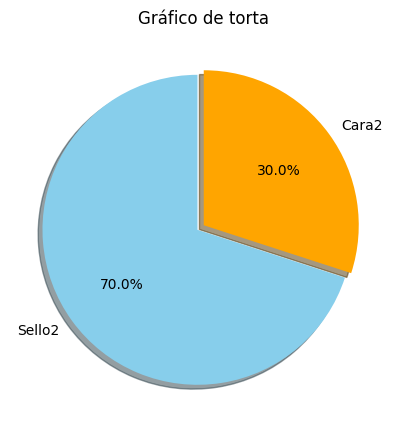

In [12]:
import random
import pandas as pd
import matplotlib.pyplot as plt

# 50 lanzamientos trucados al 70/30
lanzamientos2 = random.choices(
    ["Sello2", "Cara2"],
    weights=[0.7,0.3],
    k = 50
    )

#crear DataFrame
df2 = pd.DataFrame({
    "Respuesta2" : lanzamientos2
    })

#definir indice del 1 al 50
df2.index = range(1,51)

#crear variable de conteo con value
conteo = df2["Respuesta2"].value_counts()

#grafico de barras por separado
plt.figure(figsize=(6,4))

conteo.plot(
    kind="bar",                        # tipo de gráfico: barras verticales
    title="Gráfico de barras",         # titulo del gráfico
    color=["skyblue", "orange"],       # colores para cada categoría
    edgecolor="black"                  # borde negro para mejor definición
    )

plt.xlabel("Resultado") #nombre del eje x
plt.ylabel("Cantidad")  #nombre del eje y
plt.xticks(rotation= 0) #variables del eje x en horizontal
plt.grid(axis="y", linestyle="--", alpha=0.7) #linea vertical
plt.grid(axis="x", linestyle="--", alpha=0.7) #linea horizontales
plt.gca().set_axisbelow(True) #grillas atras del texto

plt.show()

print("\n")

#grafico de pastel por separado
plt.figure(figsize=(5, 6.64))
conteo.plot(
    kind="pie",                        # tipo de gráfico: torta
    title="Gráfico de torta",          # titulo del gráfico
    autopct="%1.1f%%",                 # mostrar porcentaje con 1 decimal
    startangle=90,                     # iniciar desde arriba, 90 grados
    colors=["skyblue", "orange"],      # mantener consistencia de colores
    explode=(0.05, 0),                 # separar ligeramente la primera categoría
    shadow=True                        # agregar sombra
    )

plt.ylabel("")

plt.show() #mostrar graficos




 3. Crear un calendario 2020 usando Pandas, incluir como mínimo semana y día, puede usarse el inglés para los nombres.

In [13]:
import pandas as pd

# generar fechas con data_range
fechas = pd.date_range(start="2020-01-01", end="2020-12-31")

# crear dataframe
df_calendario = pd.DataFrame({
    "Date": fechas,
    "Day_of_week": fechas.day_name(),
    "Week_number": fechas.isocalendar().week,
    "Month": fechas.month_name(),
    "Quarter": fechas.quarter
})

# 1.exportar a excel
!pip install python-docx
df_calendario.to_excel("Calendario_2020.xlsx", index=False)

print("excel generado correctamente")


# 2.exportar a word
from docx import Document

# crear documento
doc = Document()
doc.add_heading("Calendario 2020", level=1)

# crear tabla
tabla = doc.add_table(rows=1, cols=len(df_calendario.columns))
tabla.style = "Table Grid"

# encabezados
hdr_cells = tabla.rows[0].cells
for i, col in enumerate(df_calendario.columns):
    hdr_cells[i].text = col

# datos
for _, row in df_calendario.iterrows():
    fila = tabla.add_row().cells
    for i, col in enumerate(df_calendario.columns):
        fila[i].text = str(row[col])

# guardar word
doc.save("Calendario_2020.docx")

print("word generado correctamente")


excel generado correctamente
word generado correctamente
